# Data Exploration

In [43]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'no': '#e07b54', 'yes': '#378add'}


df_path = r"C:\Users\divye\Data_science_projects\5qaNUcRSLjHZ5anY\data\term-deposit-marketing-2020.csv"

df = pd.read_csv(df_path)

df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,no


In [44]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

# EDA 

In [45]:
eda_df = df.copy()

print(eda_df['marital'].value_counts())
print(df['education'].value_counts())
print(df['default'].value_counts())
print(df['campaign'].value_counts())

marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64
default
no     39191
yes      809
Name: count, dtype: int64
campaign
1     14718
2     11153
3      4970
4      3297
5      1642
6      1228
7       699
8       526
9       318
10      262
11      197
12      154
13      131
14       93
15       83
16       78
17       69
18       51
19       44
20       43
21       35
22       23
25       22
23       22
24       20
28       16
29       16
26       13
31       12
27       10
32        9
30        8
33        6
34        5
35        4
36        4
43        3
38        3
41        2
50        2
37        2
51        1
63        1
55        1
46        1
58        1
39        1
44        1
Name: count, dtype: int64


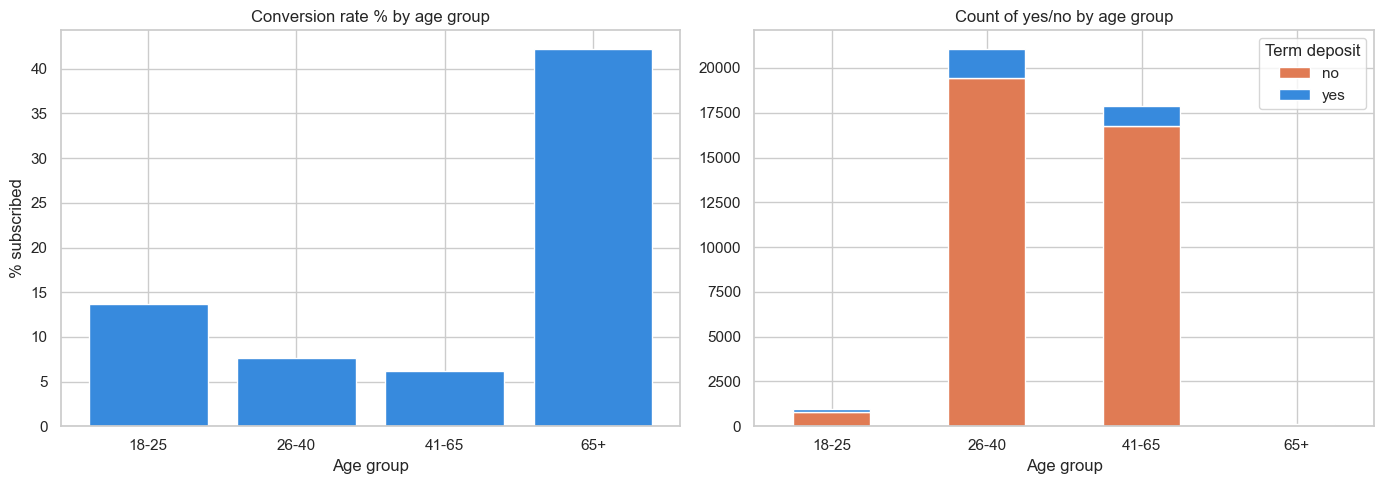

In [46]:
eda_df['age_group'] = pd.cut(eda_df['age'],
    bins=[17, 25, 40, 65, 100],
    labels=['18-25', '26-40', '41-65', '65+'])

# conversion rate per age group
age_conv = (eda_df.groupby('age_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='conversion_rate'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- plot 1: conversion rate bar ---
axes[0].bar(age_conv['age_group'].astype(str),
         age_conv['conversion_rate'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by age group')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('% subscribed')

# --- plot 2: stacked count bar ---
age_counts = pd.crosstab(eda_df['age_group'], eda_df['y'])
age_counts.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#e07b54', '#378add'], edgecolor='white')
axes[1].set_title('Count of yes/no by age group')
axes[1].set_xlabel('Age group')
axes[1].legend(title='Term deposit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

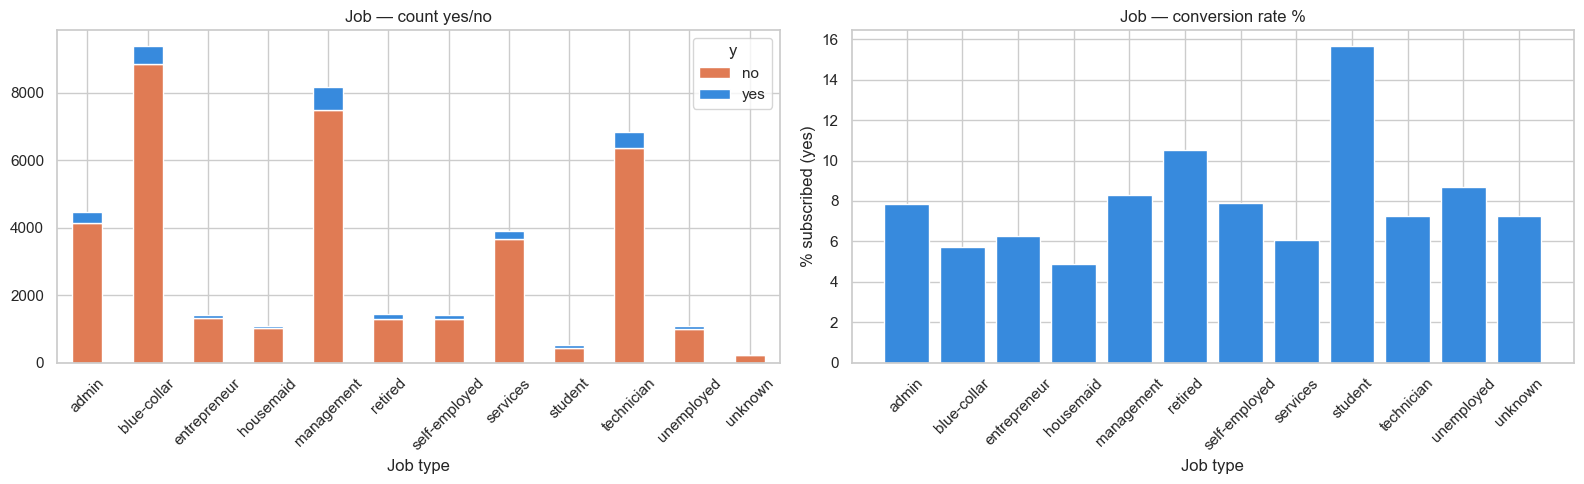

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

job_order = sorted(eda_df['job'].unique().tolist())

# Stacked count bar
job_counts = pd.crosstab(eda_df['job'], eda_df['y'])[
    ['no', 'yes']].reindex(job_order)
job_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Job — count yes/no')
axes[0].set_xlabel('Job type')
axes[0].tick_params(axis='x', rotation=45)

# Conversion rate bar
job_conv = (eda_df.groupby('job')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(job_order)
              .reset_index(name='pct_yes'))
axes[1].bar(job_conv['job'], job_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Job — conversion rate %')
axes[1].set_xlabel('Job type')
axes[1].set_ylabel('% subscribed (yes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

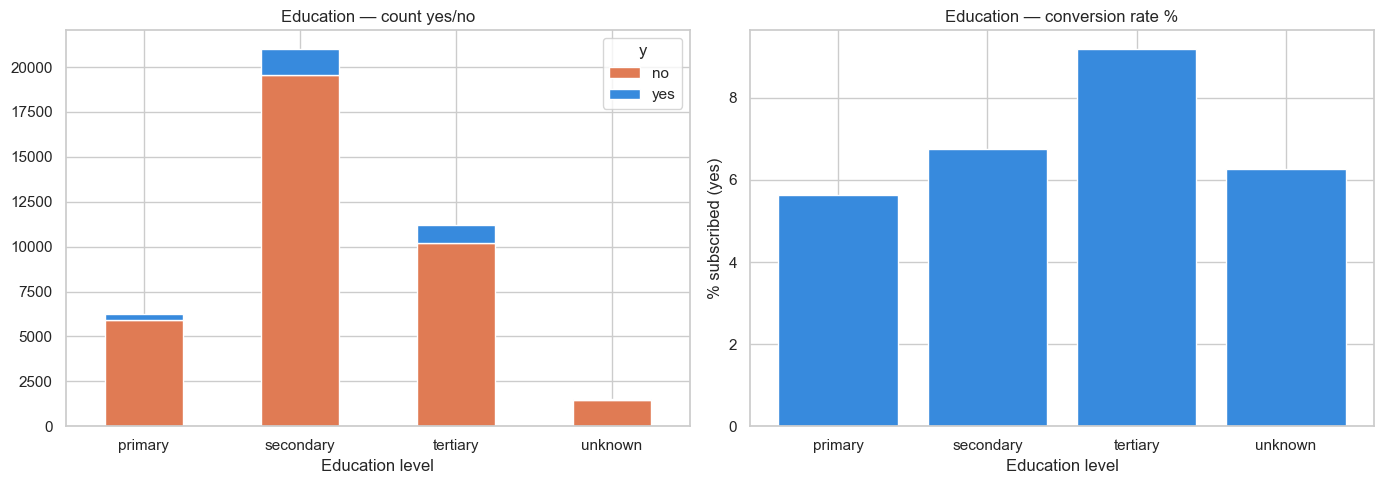

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_order = ['primary', 'secondary', 'tertiary', 'unknown']

# Stacked count bar
edu_counts = pd.crosstab(eda_df['education'], eda_df['y'])[
    ['no', 'yes']].reindex(edu_order)
edu_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Education — count yes/no')
axes[0].set_xlabel('Education level')
axes[0].tick_params(axis='x', rotation=0)

# Conversion rate bar
edu_conv = (eda_df.groupby('education')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(edu_order)
              .reset_index(name='pct_yes'))
axes[1].bar(edu_conv['education'], edu_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Education — conversion rate %')
axes[1].set_xlabel('Education level')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

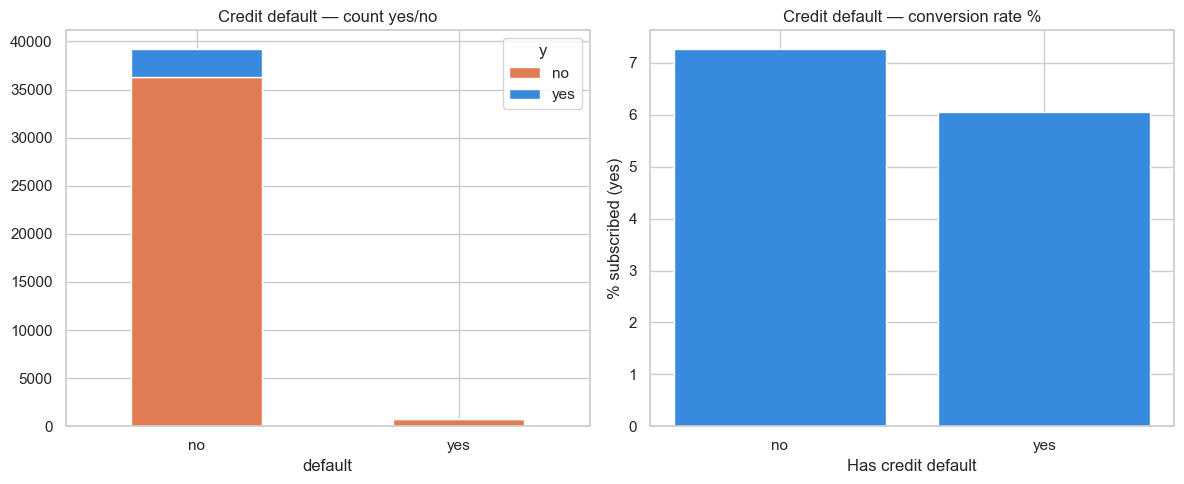

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def_counts = pd.crosstab(eda_df['default'], eda_df['y'])[['no', 'yes']]
def_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Credit default — count yes/no')
axes[0].tick_params(axis='x', rotation=0)

def_conv = (eda_df.groupby('default')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[1].bar(def_conv['default'], def_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Credit default — conversion rate %')
axes[1].set_xlabel('Has credit default')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

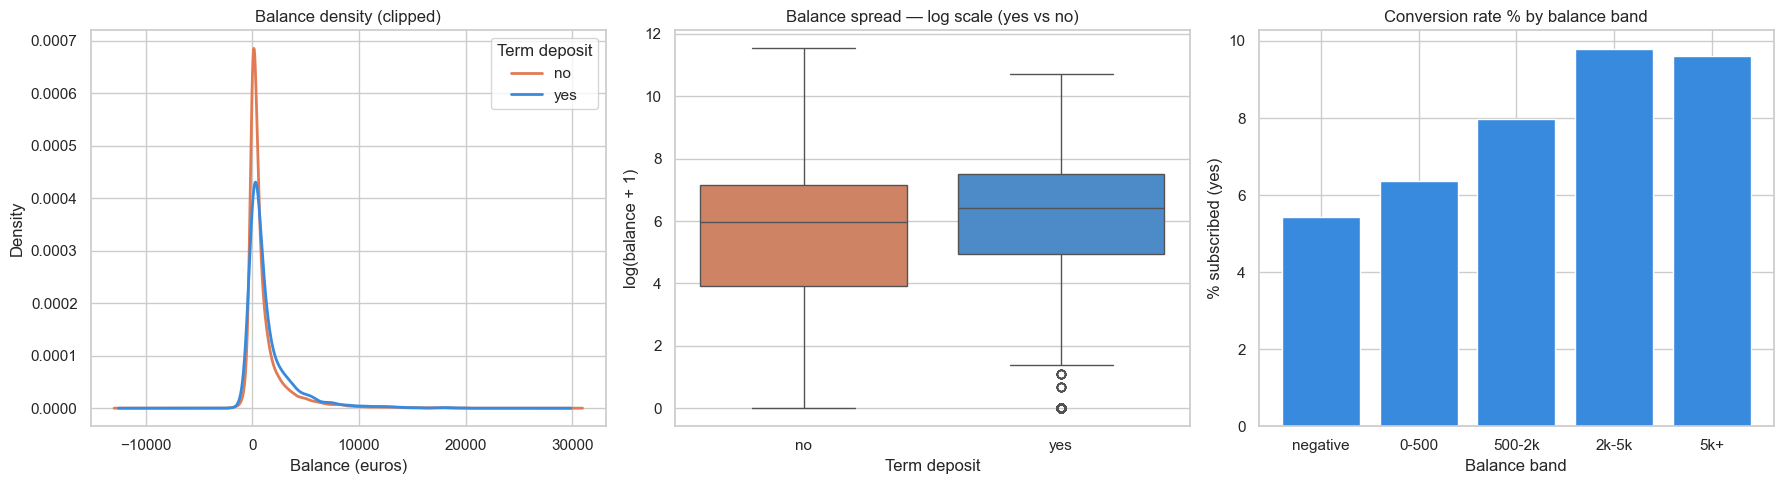

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE — clip extreme outliers for readability
bal_clip = eda_df[eda_df['balance'].between(-2000, 20000)]
for label, grp in bal_clip.groupby('y')['balance']:
    grp.plot.kde(ax=axes[0], label=label,
               linewidth=2, color=COLORS[label])
axes[0].set_title('Balance density (clipped)')
axes[0].set_xlabel('Balance (euros)')
axes[0].legend(title='Term deposit')

# shift balance so log works (balance can be 0 or negative)
eda_df['balance_log'] = np.log1p(eda_df['balance'].clip(lower=0))

sns.boxplot(data=eda_df, x='y', y='balance_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Balance spread — log scale (yes vs no)')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(balance + 1)')

# Balance bins conversion rate
eda_df['bal_group'] = pd.cut(eda_df['balance'],
    bins=[-10000, 0, 500, 2000, 5000, 100000],
    labels=['negative', '0-500', '500-2k', '2k-5k', '5k+'])
bal_conv = (eda_df.groupby('bal_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[2].bar(bal_conv['bal_group'].astype(str),
         bal_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[2].set_title('Conversion rate % by balance band')
axes[2].set_xlabel('Balance band')
axes[2].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

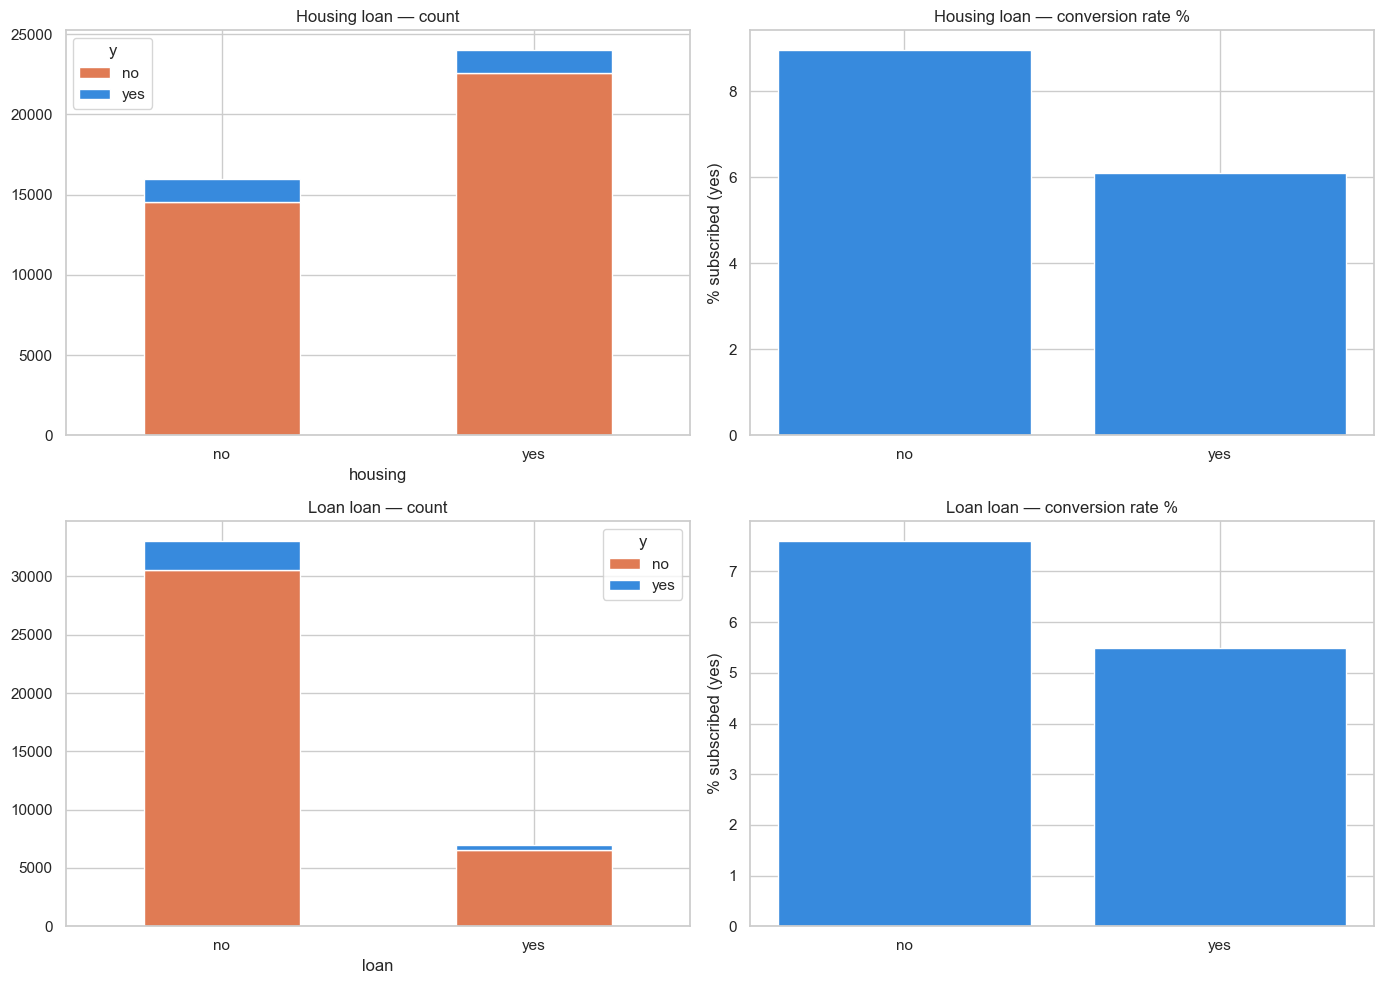

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['housing', 'loan']):
    # stacked count
    counts = pd.crosstab(eda_df[col], eda_df['y'])[['no', 'yes']]
    counts.plot(kind='bar', stacked=True, ax=axes[i][0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
    axes[i][0].set_title(f'{col.title()} loan — count')
    axes[i][0].tick_params(axis='x', rotation=0)

    # conversion rate
    conv = (eda_df.groupby(col)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
    axes[i][1].bar(conv[col], conv['pct_yes'],
             color='#378add', edgecolor='white')
    axes[i][1].set_title(f'{col.title()} loan — conversion rate %')
    axes[i][1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

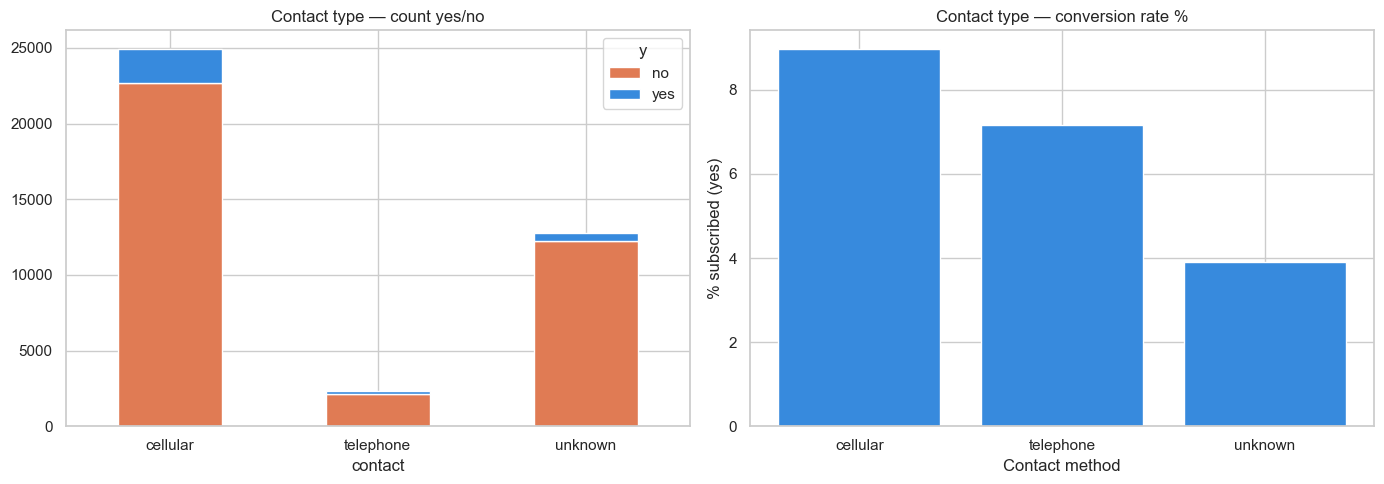

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_counts = pd.crosstab(eda_df['contact'], eda_df['y'])[['no', 'yes']]
ct_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Contact type — count yes/no')
axes[0].tick_params(axis='x', rotation=0)

ct_conv = (eda_df.groupby('contact')['y']
             .apply(lambda x: (x == 'yes').mean() * 100)
             .reset_index(name='pct_yes'))
axes[1].bar(ct_conv['contact'], ct_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Contact type — conversion rate %')
axes[1].set_xlabel('Contact method')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

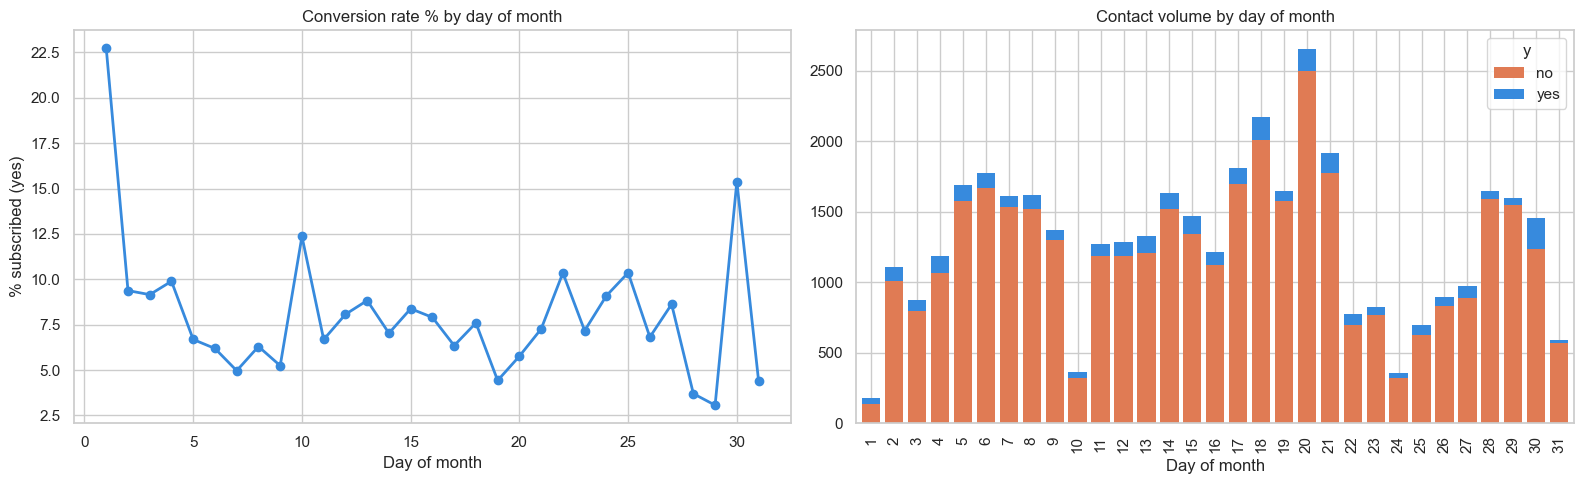

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average conversion by day
day_conv = (eda_df.groupby('day')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[0].plot(day_conv['day'], day_conv['pct_yes'],
           marker='o', color='#378add', linewidth=2)
axes[0].set_title('Conversion rate % by day of month')
axes[0].set_xlabel('Day of month')
axes[0].set_ylabel('% subscribed (yes)')

# Volume of contacts per day
day_vol = eda_df.groupby(['day', 'y']).size().unstack(fill_value=0)
day_vol.plot(kind='bar', stacked=True, ax=axes[1],
            color=[COLORS['no'], COLORS['yes']],
            edgecolor='none', width=0.8)
axes[1].set_title('Contact volume by day of month')
axes[1].set_xlabel('Day of month')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

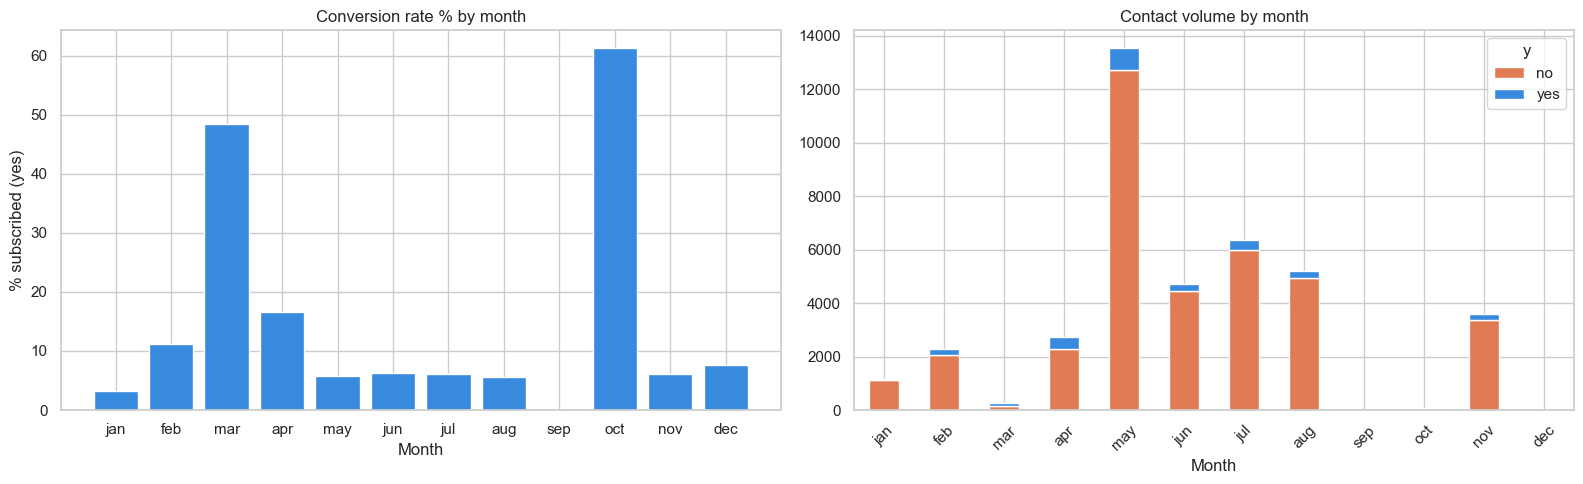

In [54]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_conv = (eda_df.groupby('month')['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reindex(month_order)
                .reset_index(name='pct_yes'))
axes[0].bar(month_conv['month'], month_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('% subscribed (yes)')

month_vol = (eda_df.groupby(['month', 'y'])
               .size().unstack(fill_value=0)
               .reindex(month_order))
month_vol.plot(kind='bar', stacked=True, ax=axes[1],
              color=[COLORS['no'], COLORS['yes']],
              edgecolor='white')
axes[1].set_title('Contact volume by month')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

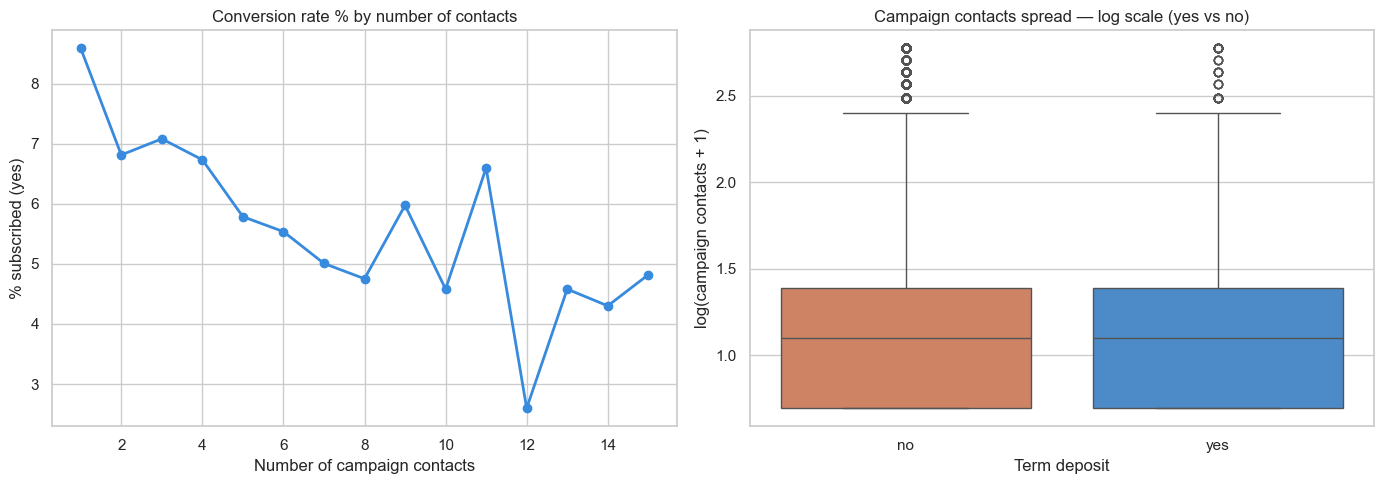

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# clip outliers — most contacts are under 15
camp_clip = eda_df[eda_df['campaign'] <= 15]

camp_conv = (camp_clip.groupby('campaign')['y']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reset_index(name='pct_yes'))
axes[0].plot(camp_conv['campaign'], camp_conv['pct_yes'],
           marker='o', color='#378add', linewidth=2)
axes[0].set_title('Conversion rate % by number of contacts')
axes[0].set_xlabel('Number of campaign contacts')
axes[0].set_ylabel('% subscribed (yes)')

# clip first then log transform
eda_df['campaign_log'] = np.log1p(eda_df['campaign'].clip(upper=15))

sns.boxplot(data=eda_df, x='y', y='campaign_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Campaign contacts spread — log scale (yes vs no)')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(campaign contacts + 1)')

plt.tight_layout()
plt.show()

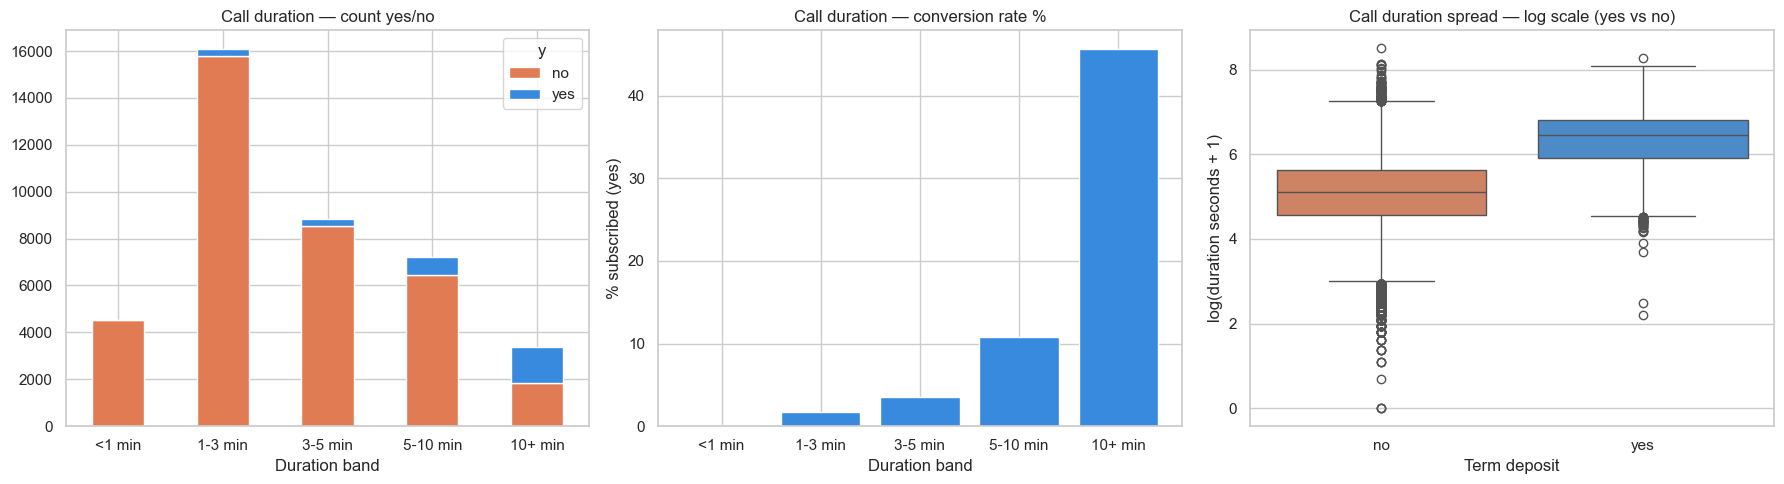

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# bin duration in seconds into readable groups
eda_df['dur_group'] = pd.cut(eda_df['duration'],
    bins=[0, 60, 180, 300, 600, 99999],
    labels=['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min'])

dur_order = ['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min']

# stacked count bar
dur_counts = pd.crosstab(eda_df['dur_group'], eda_df['y'])[
    ['no', 'yes']].reindex(dur_order)
dur_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Call duration — count yes/no')
axes[0].set_xlabel('Duration band')
axes[0].tick_params(axis='x', rotation=0)

# conversion rate bar
dur_conv = (eda_df.groupby('dur_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(dur_order)
              .reset_index(name='pct_yes'))
axes[1].bar(dur_conv['dur_group'].astype(str), dur_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Call duration — conversion rate %')
axes[1].set_xlabel('Duration band')
axes[1].set_ylabel('% subscribed (yes)')
axes[1].tick_params(axis='x', rotation=0)

# box plot with log scale to handle skew
eda_df['duration_log'] = np.log1p(eda_df['duration'])
sns.boxplot(data=eda_df, x='y', y='duration_log', ax=axes[2],
            order=['no', 'yes'], palette=COLORS)
axes[2].set_title('Call duration spread — log scale (yes vs no)')
axes[2].set_xlabel('Term deposit')
axes[2].set_ylabel('log(duration seconds + 1)')

plt.tight_layout()
plt.show()

# 📊 EDA Summary — Bank Term Deposit Campaign

---

## 1. Age
- **65+** → highest conversion (~42%) but tiny sample — not scalable alone
- **18-25** → decent conversion (~13.5%) but underreached by the campaign
- **26-40** → largest group (~21,000) but only 7.5% conversion
- **41-65** → second largest (~18,000) with worst conversion at 6.3%
- **Insight:** Campaign is spending most effort on the least receptive age groups

---

## 2. Education
- **Tertiary** → best conversion (~9%) — university educated, financially literate
- **Secondary** → most targeted (~21,000) but average conversion (~7%)
- **Primary** → lowest conversion (~6%)
- **Unknown** → treat carefully, may need imputation
- **Feature Engineering Tip:** Cross secondary with job type
```python
  eda_df['edu_job'] = eda_df['education'] + '_' + eda_df['job']
  # secondary_technician vs secondary_blue-collar behave differently
```

---

## 3. Balance
- Consistent positive signal — higher balance = higher conversion
- Conversion rises from **5.4% (negative balance)** → **9.7% (2k-5k band)**
- Heavy right skew handled with **log transformation**
- Moderate predictor on its own but reliable direction

---

## 4. Housing & Personal Loan
- Clients **without any loan** convert significantly better
- **Housing loan** gap: 8.9% (no loan) vs 6.1% (has loan) — stronger signal
- **Personal loan** gap: 7.4% (no loan) vs 5.4% (has loan) — weaker signal
- Personal loan holders are a minority (~6,500 of 40,000)
- **Feature Engineering Tip:** Combine both into a debt burden score
```python
  eda_df['debt_burden'] = (
      (eda_df['housing'] == 'yes').astype(int) +
      (eda_df['loan'] == 'yes').astype(int)
  )
  # 0 = no loans, 1 = one loan, 2 = both loans
```

---

## 5. Contact Type
- **Cellular** → best channel: highest volume (~25,000) AND best conversion (~9%)
- **Telephone** → small volume (~2,500) with decent conversion (~7.2%)
- **Unknown** → ~12,500 records (nearly a third of data), worst conversion (~4%)
- Unknown kept as its own category — likely a missing data pattern the model can learn from

---

## 6. Day & Month
- **Day of month** → weak and noisy signal, no consistent pattern
- **Best months** → March (~48%), October (~61%) but very low volume
- **Worst months** → May has ~13,500 contacts but only 6% conversion
- **Insight:** Campaign calendar needs rethinking — heaviest effort in worst months
- **Feature Engineering Tip:**
```python
  high_conv_months = ['mar', 'apr', 'oct']
  eda_df['is_high_conv_month'] = eda_df['month'].isin(high_conv_months).astype(int)
```

---

## 7. Campaign Contacts
- First contact → **8.5% conversion** — best result
- Conversion drops sharply after 3 contacts
- Yes and No groups have almost identical contact distributions
- **Insight:** Calling the same person repeatedly is wasted effort
```python
  eda_df['is_first_contact'] = (eda_df['campaign'] == 1).astype(int)
  eda_df['over_contacted']   = (eda_df['campaign'] > 3).astype(int)
```

---

## 8. Call Duration ⚠️
- **Strongest predictor** in the entire dataset
- Clear step-up pattern:

| Duration | Conversion |
|----------|------------|
| < 1 min  | ~0%        |
| 1-3 min  | ~2%        |
| 3-5 min  | ~4%        |
| 5-10 min | ~11%       |
| 10+ min  | ~45%       |

- **Critical Warning — Data Leakage Risk:**
  > Duration is only known **after** the call ends. In real deployment the model cannot use this feature because you do not know call length before making the call.
- **Recommendation:** Train two versions
  - ✅ **With duration** — shows ceiling model performance
  - ✅ **Without duration** — real world deployable model

---

## 9. Credit Default
- Vast majority have no default (~39,000 vs ~800)
- Conversion gap is small: 7.3% (no default) vs 6% (has default)
- Heavily imbalanced column — weak standalone predictor
- Worth keeping as a feature but not a dominant signal

---

## Class Imbalance
| Class | Count | % |
|-------|-------|---|
| No    | 37,104 | 92.8% |
| Yes   | 2,896  | 7.2%  |

- Model must focus on **Recall of YES** — missing a real customer is costlier than a false alarm
- Use **threshold tuning** (lower from 0.5 → 0.3) to catch more yes cases
- Avoid SMOTE on real banking data to preserve the true distribution

In [56]:
eda_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y,age_group,balance_log,bal_group,campaign_log
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no,41-65,7.670429,2k-5k,0.693147
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no,41-65,3.401197,0-500,0.693147
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no,26-40,1.098612,0-500,0.693147
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no,41-65,7.317876,500-2k,0.693147
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no,26-40,0.693147,0-500,0.693147


Train size : 32000 rows
Test size  : 8000 rows
Train yes  : 2317 (7.2%)
Test yes   : 579 (7.2%)

Classification Report (threshold = 0.3):
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      7421
         yes       0.46      0.43      0.45       579

    accuracy                           0.92      8000
   macro avg       0.71      0.70      0.70      8000
weighted avg       0.92      0.92      0.92      8000

        CONFUSION MATRIX BREAKDOWN
  True  Negative  (TN) :   7125  — correctly predicted NO
  False Positive  (FP) :    296  — said YES but actually NO
  False Negative  (FN) :    328  — said NO  but actually YES  ← minimise this
  True  Positive  (TP) :    251  — correctly predicted YES
  Recall  YES : 43.4%  (of all real yes, how many caught)
  Precision YES: 45.9%  (of predicted yes, how many right)


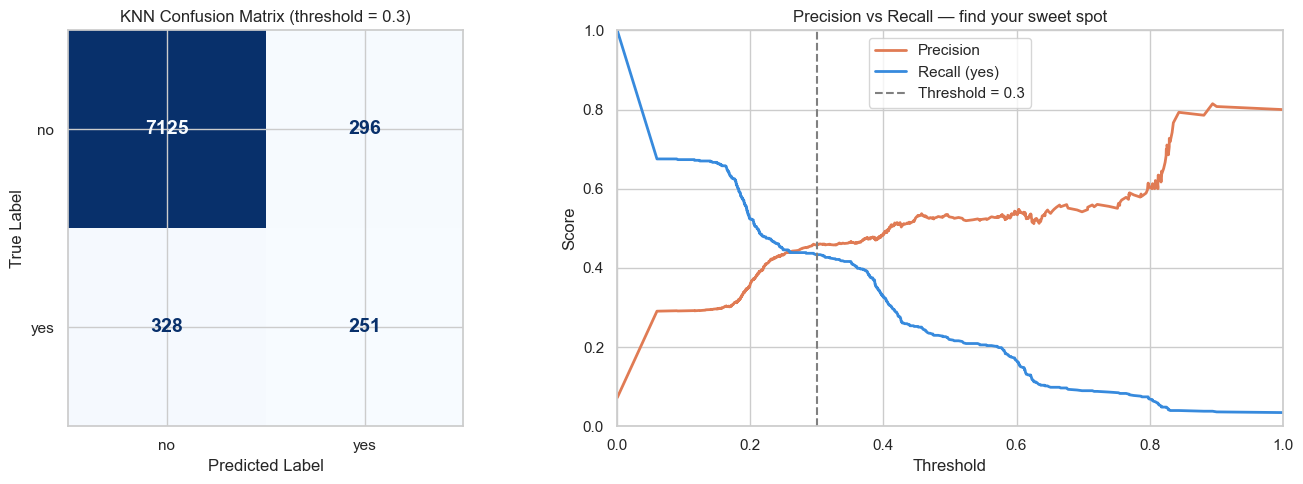

       TOP IMPORTANT FEATURES
  feature  importance_mean  importance_std
 duration         0.088066        0.004225
  housing         0.004805        0.002582
  marital         0.004141        0.004979
     loan         0.002280        0.002868
 campaign         0.000987        0.002623
  default         0.000962        0.001988
age_group         0.000136        0.005070
  contact        -0.000699        0.004078
      day        -0.001288        0.005424
    month        -0.003521        0.003301


       LEAST IMPORTANT FEATURES
     feature  importance_mean  importance_std
campaign_log        -0.005902        0.003973
   bal_group        -0.007022        0.006110
         age        -0.007403        0.001560
         job        -0.008146        0.005762
   education        -0.013697        0.005963


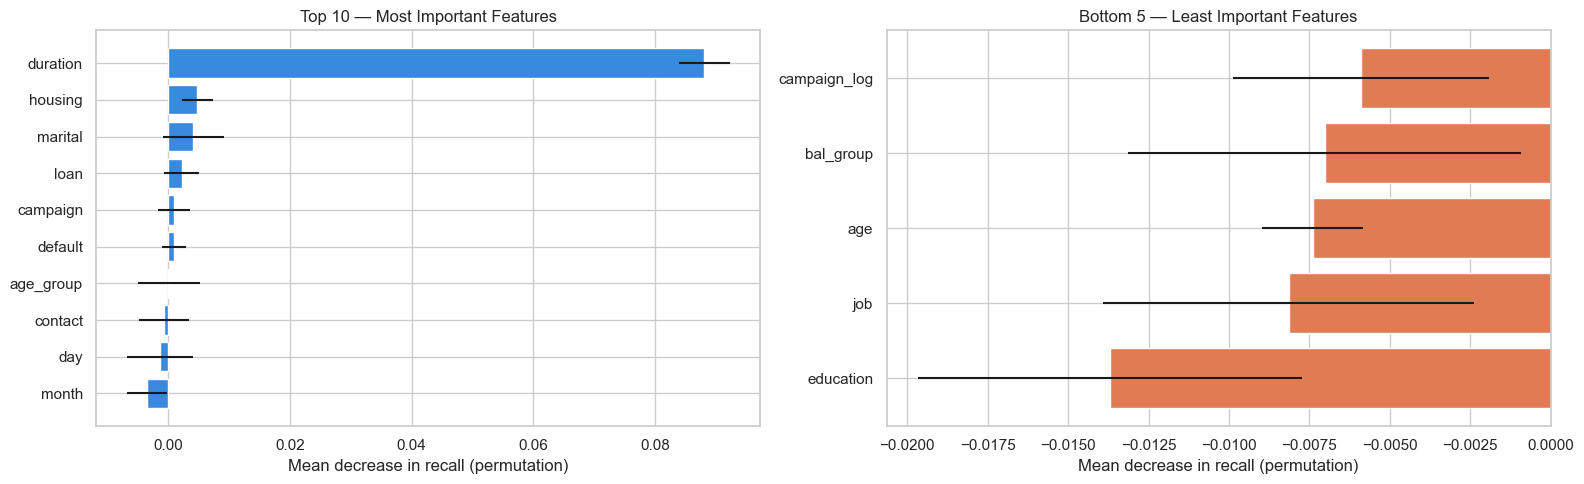

In [61]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve

# ── 1. encode categoricals ──────────────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month',
            'age_group', 'bal_group']

le = LabelEncoder()
model_df = eda_df.copy()

for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# encode target
model_df['y'] = (model_df['y'] == 'yes').astype(int)

# ── 2. select features ──────────────────────────────────────────────
features = [
    'age', 'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact',
    'day', 'month', 'duration', 'campaign',
    'balance_log', 'campaign_log',
    'age_group', 'bal_group'
]

X = model_df[features]
y = model_df['y']

# ── 3. split into train and test ────────────────────────────────────
train_df, test_df = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=y)

X_train = train_df[features]
y_train = train_df['y']
X_test  = test_df[features]
y_test  = test_df['y']

print(f"Train size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")
print(f"Train yes  : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test yes   : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# ── 4. scale — mandatory for KNN ────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── 5. train KNN with class_weight via sample_weight ────────────────
# no SMOTE — instead pass sample weights so minority class
# gets more importance during distance voting
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# ── 5. train KNN — handle imbalance via class_weight in prediction ──
# KNN does not support sample_weight or class_weight
# instead use class prior weighting via predict_proba threshold tuning
# which is the correct approach for KNN with imbalanced data

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
knn.fit(X_train, y_train)
# ── 6. tune threshold for yes recall ────────────────────────────────
y_prob = knn.predict_proba(X_test)[:, 1]

THRESHOLD = 0.3
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── 7. evaluation ───────────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD}):")
print(classification_report(y_test, y_pred_tuned, target_names=['no', 'yes']))

# ── 8. detailed confusion matrix breakdown ───────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

print("=" * 45)
print("        CONFUSION MATRIX BREAKDOWN")
print("=" * 45)
print(f"  True  Negative  (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive  (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative  (FN) : {fn:>6}  — said NO  but actually YES  ← minimise this")
print(f"  True  Positive  (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 45)
print(f"  Recall  YES : {tp/(tp+fn)*100:.1f}%  (of all real yes, how many caught)")
print(f"  Precision YES: {tp/(tp+fp)*100:.1f}%  (of predicted yes, how many right)")
print("=" * 45)

# ── 9. plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix heatmap
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0],
    colorbar=False)
axes[0].set_title(f'KNN Confusion Matrix (threshold = {THRESHOLD})')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# annotate each cell clearly
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
axes[1].plot(thresholds, precision[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds, recall[:-1],
             label='Recall (yes)', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold = {THRESHOLD}')
axes[1].set_title('Precision vs Recall — find your sweet spot')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()
from sklearn.inspection import permutation_importance

# ── feature importance via permutation ──────────────────────────────
# scoring on recall of yes (label=1) since that is our focus
perm = permutation_importance(
    knn, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall_macro',
    n_jobs=-1
)

# build importance dataframe
importance_df = pd.DataFrame({
    'feature'         : features,
    'importance_mean' : perm.importances_mean,
    'importance_std'  : perm.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print("=" * 50)
print("       TOP IMPORTANT FEATURES")
print("=" * 50)
print(importance_df.head(10).to_string(index=False))

print("\n")
print("=" * 50)
print("       LEAST IMPORTANT FEATURES")
print("=" * 50)
print(importance_df.tail(5).to_string(index=False))

# ── plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# top features
top = importance_df.head(10)
axes[0].barh(top['feature'][::-1], top['importance_mean'][::-1],
             xerr=top['importance_std'][::-1],
             color='#378add', edgecolor='white')
axes[0].set_title('Top 10 — Most Important Features')
axes[0].set_xlabel('Mean decrease in recall (permutation)')

# least features
bottom = importance_df.tail(5)
axes[1].barh(bottom['feature'][::-1], bottom['importance_mean'][::-1],
             xerr=bottom['importance_std'][::-1],
             color='#e07b54', edgecolor='white')
axes[1].set_title('Bottom 5 — Least Important Features')
axes[1].set_xlabel('Mean decrease in recall (permutation)')

plt.tight_layout()
plt.show()